In [1]:
import os, sys
script_dir = os.getcwd()
module_path = script_dir
for _ in range(5):
    module_path = os.path.abspath(os.path.join(module_path, '../'))
    if module_path not in sys.path:
        sys.path.insert(0,module_path)
    if os.path.basename(module_path) =='ATLAS':
        break
from src.unit import Unit
from src.operators import *
import src.operators
from src.operator_base import op_type_dicts
from src.system import System
import pandas as pd
from src.analye_model import *
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import itertools
from src.sparse_hw_cost import *
import seaborn as sns

/Users/abambhaniya3/Work/DL_codes/ATLAS/IEEE_MAG_Papers
/Users/abambhaniya3/Work/DL_codes/ATLAS


In [2]:
%load_ext autoreload
%autoreload 2   

In [3]:
def plot_roofline_background(system, max_x):
    op_intensity = system.flops/system.offchip_mem_bw
    flops = unit.raw_to_unit(system.flops, type='C')
    max_x = max(max_x, op_intensity*2.5)
    turning_points = [[0, 0], [op_intensity, flops], [max_x, flops]]
    turning_points = np.array(turning_points)
    plt.plot(turning_points[:,0], turning_points[:,1], c='darkgrey')

    # op_intensity = system.flops/system.onchip_mem_bw
    # flops = unit.raw_to_unit(system.flops, type='C')
    # turning_points = [[0, 0], [op_intensity, flops], [max_x, flops]]
    # turning_points = np.array(turning_points)
    # plt.plot(turning_points[:,0], turning_points[:,1], '--', c='grey')
    plt.tick_params(axis="x",labelsize=40)
    plt.tick_params(axis="y",labelsize=40)
    plt.xlabel('Op Intensity (FLOPs/Byte)', fontsize=40, fontweight='bold')
    plt.ylabel(f'{unit.unit_compute.upper()}', fontsize=40)

In [4]:
def dot_roofline(df):
    max_x = max(df['Op Intensity'])
    plot_roofline_background(system, max_x)
    colors = itertools.cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
    for i in range(len(df)):
        op_intensity = df.loc[i, 'Op Intensity']
        thrpt = df.loc[i, 'Throughput (Tflops)']
        plt.scatter(op_intensity, thrpt,linewidths=4, color=next(colors))
        if(df.loc[i, 'Bound']=='M'):
            plt.text(op_intensity*1.02 , thrpt*0.98,str(df.loc[i, 'Op Type']))
        else:
            plt.text(op_intensity  , thrpt*0.95,str(df.loc[i, 'Op Type']))

## V1


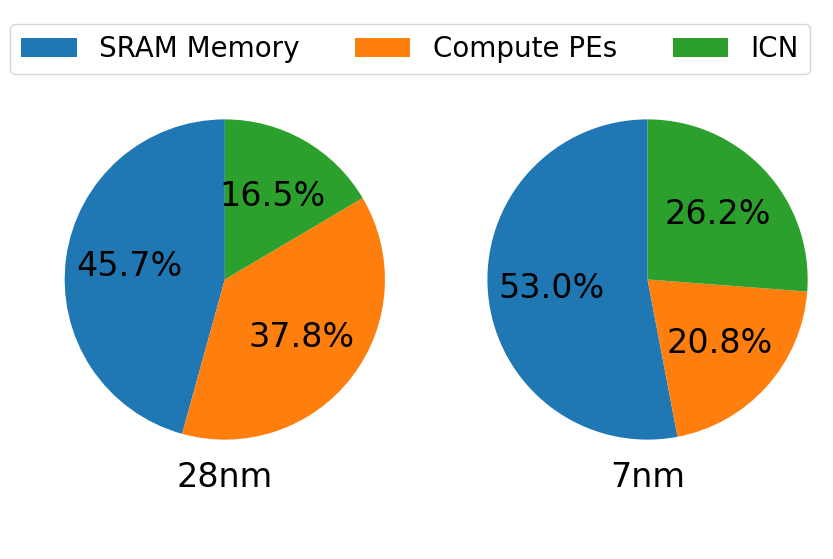

In [5]:
import matplotlib.pyplot as plt

# Define the data for the first pie chart
sizes_v4 = [53,20.8,26.2] # SRAM Memory, Compute PEs, ICN, Misc
labels = ['SRAM Memory', 'Compute PEs', 'ICN']
# colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']

# Define the data for the second pie chart
sizes_v1 = [45.7,37.8,16.5] # SRAM Memory, Compute PEs, ICN, Misc
sizes_v1_same_mem = [70,12,10.5,7.5] # SRAM Memory, Compute PEs, ICN, Misc


# Create a figure with 2 subplots
# plt.figure(figsize=(12, 14))
plt.rcParams['figure.figsize'] = [10,7]
fig, ax = plt.subplots(1, 2)

# Create the first pie chart as a subfigure
patches, _,_ = ax[1].pie(sizes_v4, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24},)
ax[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle
ax[1].set_title('7nm', y=0.1, fontsize=24)

# # Create the second pie chart as a subfigure
ax[0].pie(sizes_v1, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24})
ax[0].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle
ax[0].set_title('28nm', y=0.1, fontsize=24)
plt.legend(patches,labels, loc="best",  fontsize=20, ncol=4)

plt.savefig("TPU_v4_area_distribution.pdf", format='pdf', bbox_inches='tight', dpi=100)
# Display the figure
plt.show()


In [7]:
def convert_to_heatmap_data(df):
    numpy_df = df.iloc[:,1:][1:].copy(deep=True)
    # annotation_df = df.iloc[:,1:][1:].copy(deep=True)
    for (row, col), val in np.ndenumerate(numpy_df):
        if(numpy_df.iloc[row, col] == '1:2'):
            numpy_df.iloc[row, col] =                       20 + 2.5    #np.float64(0.5)
        elif(numpy_df.iloc[row, col] == '1:4'):
            numpy_df.iloc[row, col] =                       15 + 2.5    #np.float64(0.25)
        elif(numpy_df.iloc[row, col] == '1:8'):
            numpy_df.iloc[row, col] =                       10 + 2.5    #np.float64(0.125)
        elif(numpy_df.iloc[row, col] == '1:16'):
            numpy_df.iloc[row, col] =                       5  + 2.5    #np.float64(0.0625)
        elif(numpy_df.iloc[row, col] == 'Unstructured'):
            numpy_df.iloc[row, col] =                       0  + 2.5    #np.float64(0)
        elif(numpy_df.iloc[row, col] == 'Not Possible'):
            numpy_df.iloc[row, col] =                       -5 + 2.5    #np.float64(1)
        elif(numpy_df.iloc[row, col] == 'Dense'):
            numpy_df.iloc[row, col] =                       25 + 2.5    #np.float64(1)
    

    data=numpy_df.to_numpy(dtype=np.float64)
    return data

[36.405048408154165, 36.410785712841665, 36.514057197216665, 36.628803290966665, 37.849399295999994, 45.419279155199995, 60.559038873599995]


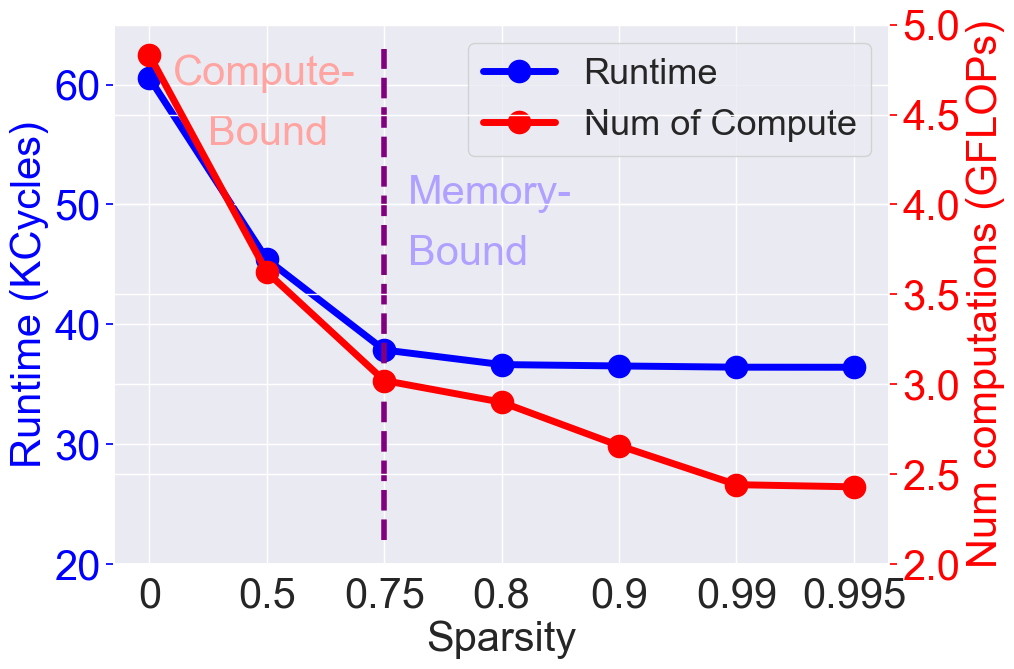

In [11]:
## Figure 5, incremental runtime improve ment


plt.rcParams['figure.figsize'] = [10,7]
plt.rcParams['figure.facecolor']='#FFFFFF'
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

seq_len = 512
# plt.subplot(121)
density_list = [1,1/2,0.25,0.2,0.1,0.01,0.005]
for sparse_pe_support in [0.0001]:
    total_latency = []
    total_compute = []
    sparsity_list = []
    for density in density_list[::-1]:
        sparsity_list.append(1-density)
        model = 'BERT'
        data_path = os.path.join(module_path,"data")

        model_path = os.path.join(data_path,"model")
        model = create_model(seq_len, name=model, data_path=data_path,method='sparse_op',spattn_density=density,spff_density=density)

        batch_size = 4
        unit = Unit()
        system = System(unit,flops=75, skip_compute=True,pe_min_density_support=sparse_pe_support, compress_mem=True)
        model_df = get_model_df(model, system, unit, batch_size, data_path, sparse=True,intermediate_on_chip=True )
        # dot_roofline(model_df,label=density)
        # display(model_df)
        # print(density*100,get_summary_table(model_df,system,unit).loc[0,'Cycles']/100000)
        total_latency.append(get_summary_table(model_df,system,unit).loc[0,'Cycles']/1000)
        total_compute.append(get_summary_table(model_df,system,unit).loc[0,'MACs (MFLOP)']/1000)
        # if(sparse_pe_support==0.0001):
            # print(1-density,get_summary_table(model_df,system,unit).loc[0,'MACs (MFLOPS)'])
        
        # print(model_df.loc[0,'Cycles'],",",model_df.loc[3,'Cycles'],",",model_df.loc[4,'Cycles'],",",model_df.loc[6,'Cycles'])
    if(sparse_pe_support==0.0001):
        legend_name =  'Unstructured' 
    else:
        legend_name =  'M = ' + str(int(1/sparse_pe_support)) 
    x_tick = list(range(len(density_list)))
    ln1 = ax1.plot(x_tick,total_latency, linewidth=5, marker='o', markersize=16, color="blue", label='Runtime')
    ln2 = ax2.plot(x_tick,total_compute, linewidth=5, marker='o', markersize=16, color="red",  label='Num of Compute')
    # ax2.bar(x_tick,total_compute, linewidth=5,  color="red",  label='Num of FLOPS',alpha=0.7)
    print(total_latency)
ax1.set_ylim(20,65)
ax2.set_ylim(2,5)
lns = ln1+ln2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0,fontsize=26)
# ax1.legend(fontsize=30)
# ax2.legend(fontsize=30, loc=)
# ax1.legend(loc = 'upper right', fontsize=30)
ax1.tick_params(axis="x",labelsize=30)
ax1.tick_params(axis="y",labelsize=30,  color="blue", labelcolor='blue')
ax2.tick_params(axis="y",labelsize=30,  color="red",  labelcolor='red')
ax1.set_ylabel("Runtime (KCycles)", fontsize=30,  color="blue")
ax2.set_ylabel("Num computations (GFLOPs)", fontsize=30,  color="red")

ax1.set_xlabel("Sparsity", fontsize=30)
my_xticks = map(str,sparsity_list)
plt.xticks(x_tick, my_xticks)
ax1.invert_xaxis()
# plt.figure(figsize=(20, 15), dpi=80)
ax1.text(   5.8 , 60,"Compute-",fontsize=30, color="#FFA4A1")
ax1.text(   5.5 , 55,"Bound",fontsize=30, color="#FFA4A1")
ax1.text(   3.8 , 50,"Memory-",fontsize=30, color="#B0A0FF")
ax1.text(   3.8 , 45,"Bound",fontsize=30, color="#B0A0FF")
# print(ax1.get_ylim()[0])
ax1.vlines(x = 4, ymin = ax1.get_ylim()[0] + 2, ymax = ax1.get_ylim()[1] - 2,
           colors = 'purple',
           ls='--',linewidth=4)
title_name = 'Seq Len = ' + str(seq_len)
# # plt.title(title_name, fontsize=30)

# ax1.set_facecolor("#515151")

plt.savefig('Figures-Runtime vs FLOPS improvement.drawio.pdf', bbox_inches='tight', pad_inches=0)

## V2


In [14]:

data_path = os.path.join(module_path,"data")
model_path = os.path.join(data_path,"model")

unit = Unit()
model="vit"
seq_len = 512
batch_size = 4
generated_model=create_inference_moe_prefix_model(input_sequence_length=seq_len,output_gen_tokens = 0 , 
                                        name=model,data_path=data_path, tensor_parallel=1, method='sparse_FF',spff_density=0.25)


Max_Dim = 256
mxu_shapes = [[1,1,Max_Dim,Max_Dim],[2,2,Max_Dim/2,Max_Dim/2],[4,4,Max_Dim/4,Max_Dim/4],[8,8,Max_Dim/8,Max_Dim/8],[16,16,Max_Dim/16,Max_Dim/16],[32,32,Max_Dim/32,Max_Dim/32]]
data = []
unstruct_BW = 1
for sparse_pe in [1,0.5,0.25,0.125,0.00001,0.00001,0.00001]:
    if(sparse_pe == 0.00001):
        unstruct_BW *= 2 
    row = []
    for shape in mxu_shapes:
        if(sparse_pe == 0.00001):   
            
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=1200 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=Max_Dim/2 , mxu_shape=shape, accelerator_type="unstructured", unstructured_efficiency=(0.66 + 0.01*unstruct_BW))
            system.set_pe_min_density_support(sparse_pe)
            
        else:
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=1200 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=Max_Dim/2 , mxu_shape=shape, accelerator_type="structured")
            system.set_pe_min_density_support(sparse_pe)

        model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
        df = get_summary_table(model_df,system,unit)
        # if sparse_pe == 1 and shape == [1,1,Max_Dim,Max_Dim]:
            # display_df(model_df)
            # display(df)
        area, BW = get_HW_cost(system,sparse_pe_support=sparse_pe, print_distribution=False, unstructure_BW=unstruct_BW)
        if(shape ==[1,1,Max_Dim,Max_Dim] and sparse_pe == 1):
            # display_df(model_df)
            monolithic_cycles = df.loc[0,'Cycles']/1000000
            monolithic_energy = df.loc[0,'Energy']
            monolithic_area   = area
        merit = 5*merit_function(speedup=(monolithic_cycles/(df.loc[0,'Cycles']/1000000)), area = (area/monolithic_area), energy=(df.loc[0,'Energy']/monolithic_energy))
        # print( f"For {shape} with 1:{int(1/sparse_pe)}sparsity Merit: {merit: 0.4f}, Cycles : {df.loc[0,'Cycles']/1000000 : 0.4f} , Energy:{df.loc[0,'Energy']: 0.4f} , area:{area: 0.4f}")
        row.append(merit)
    print(row)
    data.append(row)
        

[1.0, 0.96154581457526, 0.8855587669265921, 0.7849268738164807, 0.6195368976802573, 0.42954966263493244]
[1.8486552670433232, 1.75769113714756, 1.5837943368753813, 1.3647469765000042, 1.0300677361089665, 0.6800188823744093]
[2.3209751224398523, 2.289082514693655, 2.0578829154724745, 1.7120449109381042, 1.3125310281150984, 0.8696380449147899]
[1.5222509012377547, 1.512620500126629, 1.408085548772024, 1.2661337537151947, 1.0140726037389973, 0.7265216971217708]
[2.5250971924684618, 2.3777572514403373, 2.2167645245549137, 1.820596114582126, 1.341208800407795, 0.8967986515460249]
[2.2141835951297995, 2.1851399590965617, 1.973489574213494, 1.6532282122445627, 1.2776824399189655, 0.8542014496080454]
[1.479525362783702, 1.4704263589496813, 1.3714512152164313, 1.2364355647876475, 0.9949326180204419, 0.7166445554090263]


In [15]:
## Server Inference
model_list =        ['Llama3_1B', 'Gemma2_2B', 'Llama3_3B', 'Llama3_8B', 'Gemma2_27B', 'Qwen2.5_32B', 'Llama3_70B', 'Qwen2.5_72B', 'Llama3_405B']
num_layers     =    [  16,  26,28,  32,   46,  64,  80, 80, 126]
tensor_parallel_list = [1, 1, 1, 1, 2, 2, 8, 8, 16]
workload_ratio =    [   3,  5,  7,  10,   10,  12,  20, 18, 15]

spff_density  =     [1, 1, 1,  0.5,0.5  , 0.5  ,0.25 , 0.25  , 0.125  ]
batch_size_list =     [ 128,    96,  96,     64,     16,   16,     8,    8,   4]
input_len_list   =    [ 512,   768, 768,   1024,   1024, 1024,  1024, 1024,  2048]
output_len_list   =   [ 256,   256, 256,    256,    256,  256,   256,  256,  256]

repetation_list = [a*b for a,b in zip(workload_ratio,num_layers)]

Max_Dim  = 256
mxu_shapes = [[1,1,Max_Dim,Max_Dim],[1,2,(Max_Dim/2),Max_Dim],[2,2,(Max_Dim/2),(Max_Dim/2)],[2,4,(Max_Dim/4),(Max_Dim/2)],[4,4,(Max_Dim/4),(Max_Dim/4)]]
# mxu_shapes = [[1,1,Max_Dim,Max_Dim]]


unstruct_BW = 1
data_server_inference = []

## Sparsity Sweep
for sparse_pe in [1,0.5,0.25,0.125,0.00001,0.00001,0.00001]:
# for sparse_pe in [0.00001]:
    if(sparse_pe == 0.00001):
        unstruct_BW *= 2
    row = []

    ## Shape sweep
    for shape in mxu_shapes:
        # row.append(shape)
        if(sparse_pe == 0.00001):
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=5000 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=Max_Dim/2 , mxu_shape=shape, accelerator_type="unstructured", compute_efficiency=(0.5 + 0.01*unstruct_BW))
            system.set_pe_min_density_support(sparse_pe)
        else:
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=5000 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=Max_Dim/2 , mxu_shape=shape, accelerator_type="structured")
            system.set_pe_min_density_support(sparse_pe)

        ## Workload sweep
        cycles = 0
        energy = 0
        for model,repetation,sparsity,batch_size, input_len, output_len, tp in zip(model_list,repetation_list,spff_density,batch_size_list, input_len_list, output_len_list, tensor_parallel_list):
            # generated_model = create_model(seq_len, name=model, data_path=data_path,method='sparse_FF',spff_density=sparsity)
            # Prefill
            generated_model = create_inference_moe_prefix_model(input_sequence_length=input_len,output_gen_tokens = 0,
                                        name=model,data_path=data_path, tensor_parallel=tp, method='sparse_FF',spff_density=sparsity)
            model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
            # display_df(model_df)
            df = get_summary_table(model_df,system,unit)
            cycles += repetation * df.loc[0,'Cycles']/1000000
            energy += repetation * df.loc[0,'Energy']
            ## Generation
            generated_model = create_inference_moe_decode_model(input_sequence_length=input_len,output_gen_tokens = output_len//2,
                                        name=model,data_path=data_path, tensor_parallel=tp, method='sparse_FF',spff_density=sparsity)
            model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
            # display_df(model_df)
            df = get_summary_table(model_df,system,unit)
            cycles += output_len * repetation * df.loc[0,'Cycles']/1000000
            energy += output_len * repetation * df.loc[0,'Energy']
        # display_df(model_df)
        area, BW = get_HW_cost(system,sparse_pe_support=sparse_pe, print_distribution=False, unstructure_BW=unstruct_BW)
        if(shape ==[1,1,Max_Dim,Max_Dim] and sparse_pe == 1):
            # display_df(model_df)
            monolithic_cycles = cycles
            monolithic_energy = energy
            monolithic_area   = area
        merit = 5*merit_function(speedup=(monolithic_cycles/cycles), area = (area/monolithic_area), energy=(energy/monolithic_energy))
        print( f"For {shape} with {sparse_pe} sparsity Merit: {merit: 0.4f}, Cycles : {df.loc[0,'Cycles']/1000000 : 0.4f} , Energy:{df.loc[0,'Energy']: 0.4f} , area:{area: 0.4f}")
        row.append(merit)
    # print(row)
    data_server_inference.append(row)


For [1, 1, 256, 256] with 1 sparsity Merit:  1.0000, Cycles :  0.0760 , Energy: 8.1518 , area: 289.1375
For [1, 2, 128.0, 256] with 1 sparsity Merit:  1.0378, Cycles :  0.0760 , Energy: 7.6368 , area: 295.2277
For [2, 2, 128.0, 128.0] with 1 sparsity Merit:  1.0459, Cycles :  0.0760 , Energy: 7.6386 , area: 282.4478
For [2, 4, 64.0, 128.0] with 1 sparsity Merit:  1.0396, Cycles :  0.0760 , Energy: 7.6386 , area: 288.5379
For [4, 4, 64.0, 64.0] with 1 sparsity Merit:  1.0410, Cycles :  0.0760 , Energy: 7.6424 , area: 282.4473
For [1, 1, 256, 256] with 0.5 sparsity Merit:  1.3294, Cycles :  0.0760 , Energy: 8.1518 , area: 289.1375
For [1, 2, 128.0, 256] with 0.5 sparsity Merit:  1.3807, Cycles :  0.0760 , Energy: 7.6368 , area: 295.2277
For [2, 2, 128.0, 128.0] with 0.5 sparsity Merit:  1.3916, Cycles :  0.0760 , Energy: 7.6386 , area: 282.4478
For [2, 4, 64.0, 128.0] with 0.5 sparsity Merit:  1.3831, Cycles :  0.0760 , Energy: 7.6386 , area: 288.5379
For [4, 4, 64.0, 64.0] with 0.5 spar

,0,1,2,3,4
0,1.00,1.04,1.05,1.04,1.04
1,1.33,1.38,1.39,1.38,1.38
2,1.26,1.38,1.35,1.43,1.34
3,0.93,1.20,0.98,1.20,0.98
4,0.85,0.89,0.88,0.89,0.91
5,0.79,0.87,0.85,0.90,0.85
6,0.62,0.80,0.65,0.79,0.65


1.4264303559150027


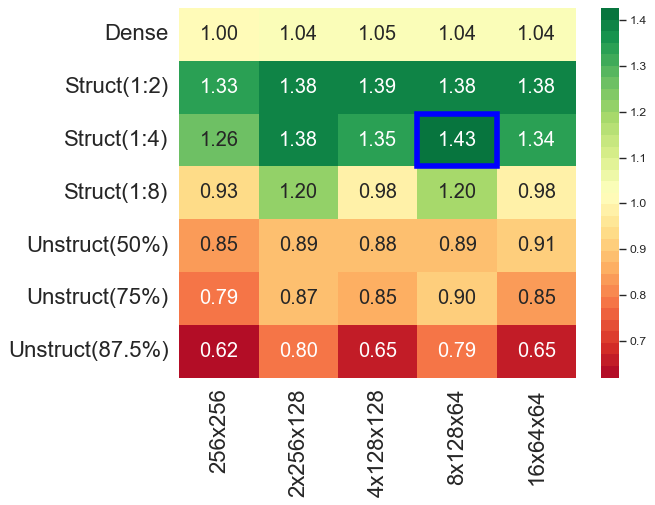

In [16]:
from matplotlib.patches import Rectangle

df_server_inference=pd.DataFrame(data_server_inference)
display(df_server_inference)

# from turtle import position

fig = plt.figure(figsize=(8,6), dpi=80)

x_axis_labels = []
for shape in mxu_shapes:
  x_axis_labels += str(shape)
y_axis_labels = ['Dense','Struct(1:2)','Struct(1:4)','Struct(1:8)','Unstruct(50%)','Unstruct(75%)','Unstruct(87.5%)']

cmap = sns.mpl_palette("RdYlGn",32)
ax = sns.heatmap(np.array(data_server_inference), annot=True, fmt=".2f", annot_kws={"fontsize":18}, cmap=cmap, 
                  yticklabels=y_axis_labels, xticklabels=['256x256', '2x256x128', '4x128x128', '8x128x64', '16x64x64']
                )
for label in ax.get_yticklabels():
  label.set_size(20) 


for label in ax.get_xticklabels():
  label.set_size(20)
  label.set_rotation(90) 


max_value = max(df_server_inference.values.flatten())
print(max_value)
max_y, max_x = divmod(df_server_inference.values.argmax(), df_server_inference.shape[1])
ax.add_patch(Rectangle((max_x, max_y), 1, 1, fill=False, edgecolor='blue', lw=5))



plt.savefig('server_inference.pdf', bbox_inches='tight', pad_inches=0)
# plt.show()

For Server based inference, 1:4 with 2x256x128 seems to be most suprior

In [17]:
## Server Training
model_list =        ['Llama3_1B', 'Gemma2_2B', 'Llama3_3B', 'Llama3_8B', 'Gemma2_27B', 'Qwen2.5_32B', 'Llama3_70B', 'Qwen2.5_72B', 'Llama3_405B']
tensor_parallel_list = [1, 1, 1, 1, 2, 2, 8, 8, 16]
num_layers     =    [16,   26    ,  28        ,   32    ,   46    ,  64  ,  80  ,  80 ,  126]
workload_ratio =    [14,      10    ,  10    ,   30    ,   15    ,  3  ,  6   ,   12  ]

spff_density  =    [1, 1, 1,  0.5,0.5  , 0.5  ,0.25 , 0.25  , 0.125  ]

batch_size_list =     [ 8,    8,  8,  8,     8,   8,     4,    4,   4]
input_len_list   =    [ 4096,   4096, 8192,   8192,   8192, 8192,  16384, 16384,  32*1024]

repetation_list = [a*b for a,b in zip(workload_ratio,num_layers)]

Max_Dim  = 256
mxu_shapes = [[1,1,Max_Dim,Max_Dim],[1,2,(Max_Dim/2),Max_Dim],[2,2,(Max_Dim/2),(Max_Dim/2)],[2,4,(Max_Dim/4),(Max_Dim/2)],[4,4,(Max_Dim/4),(Max_Dim/4)]]
# mxu_shapes = [[1,1,Max_Dim,Max_Dim]]


unstruct_BW = 1
data_training = []

## Sparsity Sweep
for sparse_pe in [1,0.5,0.25,0.125,0.00001,0.00001,0.00001]:
# for sparse_pe in [0.00001]:
    if(sparse_pe == 0.00001):
        unstruct_BW *= 2
    row = []

    ## Shape sweep
    for shape in mxu_shapes:
        # row.append(shape)
        if(sparse_pe == 0.00001):
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=5000 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=Max_Dim/2 , mxu_shape=shape, accelerator_type="unstructured", compute_efficiency=(0.5 + 0.01*unstruct_BW))
            system.set_pe_min_density_support(sparse_pe)
        else:
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=5000 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=Max_Dim/2 , mxu_shape=shape, accelerator_type="structured")
            system.set_pe_min_density_support(sparse_pe)

        ## Workload sweep
        cycles = 0
        energy = 0
        for model,repetation,sparsity,seq_len,batch_size, tp in zip(model_list,repetation_list,spff_density,input_len_list,batch_size_list, tensor_parallel_list):
            # print(model,repetation,sparsity,seq_len,batch_size, tp)
            generated_model = create_inference_moe_prefix_model(input_sequence_length=seq_len, output_gen_tokens = 0,
                name=model,data_path=data_path, tensor_parallel=tp, method='sparse_FF',spff_density=sparsity)
            model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
            # display_df(model_df)
            df = get_summary_table(model_df,system,unit)
            cycles += repetation * df.loc[0,'Cycles']/1000000
            energy += repetation * df.loc[0,'Energy']
        # display_df(model_df)
        area, BW = get_HW_cost(system,sparse_pe_support=sparse_pe, print_distribution=False, unstructure_BW=unstruct_BW)
        if(shape ==[1,1,Max_Dim,Max_Dim] and sparse_pe == 1):
            # display_df(model_df)
            monolithic_cycles = cycles
            monolithic_energy = energy
            monolithic_area   = area
        merit = 5*merit_function(speedup=(monolithic_cycles/cycles), area = (area/monolithic_area), energy=(energy/monolithic_energy))
        print( f"For {shape} with {sparse_pe}sparsity Merit: {merit: 0.4f}, Cycles : {df.loc[0,'Cycles']/1000000 : 0.4f} , Energy:{df.loc[0,'Energy']: 0.4f} , area:{area: 0.4f}")
        row.append(merit)
    # print(row)
    data_training.append(row)

For [1, 1, 256, 256] with 1sparsity Merit:  1.0000, Cycles :  143.5238 , Energy: 1761.5519 , area: 289.1375
For [1, 2, 128.0, 256] with 1sparsity Merit:  0.9887, Cycles :  143.5238 , Energy: 1788.6031 , area: 295.2277
For [2, 2, 128.0, 128.0] with 1sparsity Merit:  0.9925, Cycles :  143.5238 , Energy: 1789.8368 , area: 282.4478
For [2, 4, 64.0, 128.0] with 1sparsity Merit:  0.9747, Cycles :  143.5238 , Energy: 1841.2415 , area: 288.5379
For [4, 4, 64.0, 64.0] with 1sparsity Merit:  0.9691, Cycles :  143.5238 , Energy: 1846.4067 , area: 282.4473
For [1, 1, 256, 256] with 0.5sparsity Merit:  1.7160, Cycles :  97.9763 , Energy: 1373.5016 , area: 289.1375
For [1, 2, 128.0, 256] with 0.5sparsity Merit:  1.6935, Cycles :  97.9763 , Energy: 1399.2039 , area: 295.2277
For [2, 2, 128.0, 128.0] with 0.5sparsity Merit:  1.7010, Cycles :  97.9763 , Energy: 1401.7865 , area: 282.4478
For [2, 4, 64.0, 128.0] with 0.5sparsity Merit:  1.6670, Cycles :  97.9763 , Energy: 1444.2577 , area: 288.5379
For 

,0,1,2,3,4
0,1.00,0.99,0.99,0.97,0.97
1,1.72,1.69,1.70,1.67,1.65
2,1.64,1.74,1.68,1.77,1.64
3,1.14,1.46,1.16,1.43,1.14
4,0.91,0.92,0.90,0.90,0.91
5,0.85,0.90,0.87,0.91,0.85
6,0.65,0.82,0.66,0.80,0.65


1.766424993357689


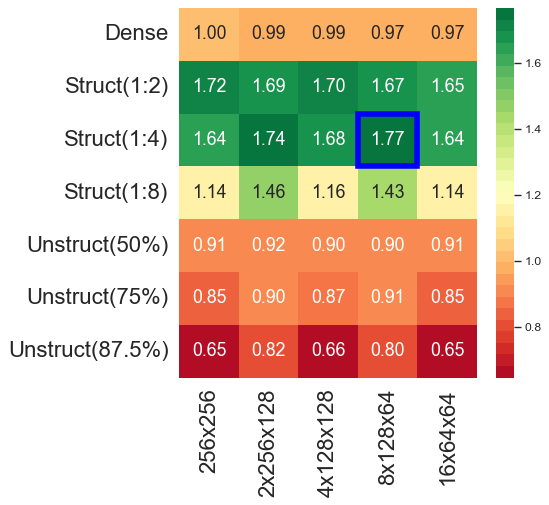

In [18]:
from matplotlib.patches import Rectangle

df_training=pd.DataFrame(data_training)
display(df_training)

# from turtle import position

fig = plt.figure(figsize=(6,6), dpi=80)

x_axis_labels = []
for shape in mxu_shapes:
    x_axis_labels += str(shape)
y_axis_labels = ['Dense','Struct(1:2)','Struct(1:4)','Struct(1:8)','Unstruct(50%)','Unstruct(75%)','Unstruct(87.5%)']

cmap = sns.mpl_palette("RdYlGn",32)
ax = sns.heatmap(df_training, annot=True, fmt=".2f", annot_kws={"fontsize":16},cmap=cmap,yticklabels=y_axis_labels , xticklabels=['256x256' , '2x256x128','4x128x128','8x128x64','16x64x64'])

for label in ax.get_yticklabels():
  label.set_size(20)

for label in ax.get_xticklabels():
  label.set_size(20)
  label.set_rotation(90)



max_value = max(df_training.values.flatten())
print(max_value)
max_y, max_x = divmod(df_training.values.argmax(), df_training.shape[1])
ax.add_patch(Rectangle((max_x, max_y), 1, 1, fill=False, edgecolor='blue', lw=5))



plt.savefig('server_training.pdf', bbox_inches='tight', pad_inches=0)
# plt.show()

For training also 2*256*128 and 8*128*64 makes the biggest impact

In [19]:
## Edge inference (TCO = Area + 2x4*Energy)
model_list =        ['Llama3_1B', 'Gemma2_2B', 'Llama3_3B', 'Llama3_8B', 'Gemma2_27B', 'Qwen2.5_32B', 'Llama3_70B', 'Qwen2.5_72B', 'Llama3_405B']
tensor_parallel_list = [1, 1, 1, 1, 1, 1, 1, 1, 1]

num_layers     =    [16,    26    ,  28 ,   32    ,   46   ,  64,  80,  80,  126]
workload_ratio =    [30,    25    ,  20 ,   15    ,   5    ,  5 ,   0,   0,   0 ]

spff_density  =     [0.125,    0.125, 0.125  , 0.0625 , 0.03125  , 0.03125, 0.01 ,0.01 , 0.01  ]
batch_size_list =     [ 8,    8,  4,     4,       1,   1,     0,    0,   0]
input_len_list   =    [ 256,   256, 256, 512,  512, 512,  0, 0,  0]
output_len_list   =   [ 32,   32, 64,    128,   128,  128,   0,  0,  0]


repetation_list = [a*b for a,b in zip(workload_ratio,num_layers)]

Max_Dim  = 64
mxu_shapes = [[1,1,Max_Dim,Max_Dim],[1,2,(Max_Dim/2),Max_Dim],[2,2,(Max_Dim/2),(Max_Dim/2)],[2,4,(Max_Dim/4),(Max_Dim/2)],[4,4,(Max_Dim/4),(Max_Dim/4)]]
# mxu_shapes = [[1,1,Max_Dim,Max_Dim]]


unstruct_BW = 1
data_edge_inference_1x_energy = []
data_edge_inference_2x_energy = []
data_edge_inference_3x_energy = []
data_edge_inference_4x_energy = []

## Sparsity Sweep
for sparse_pe in [1,0.5,0.25,0.125,0.00001,0.00001,0.00001]:
# for sparse_pe in [0.00001]:
    if(sparse_pe == 0.00001):
        unstruct_BW *= 2
    row_1x = []
    row_2x = []
    row_3x = []
    row_4x = []
    ## Shape sweep
    for shape in mxu_shapes:
        # row.append(shape)
        if(sparse_pe == 0.00001):
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=32 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=8 , mxu_shape=shape, accelerator_type="unstructured", compute_efficiency=(0.70 + 0.01*unstruct_BW))
            system.set_pe_min_density_support(sparse_pe)
        else:
            system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=32 ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=8 , mxu_shape=shape, accelerator_type="structured")
            system.set_pe_min_density_support(sparse_pe)

        ## Workload sweep
        cycles = 0
        energy = 0
        for model,repetition,sparsity,batch_size, input_len, output_len, tp in zip(model_list,repetation_list,spff_density,batch_size_list, input_len_list, output_len_list, tensor_parallel_list):
            # generated_model = create_model(seq_len, name=model, data_path=data_path,method='sparse_FF',spff_density=sparsity)
            if repetition > 0:
                # Prefill
                generated_model = create_inference_moe_prefix_model(input_sequence_length=input_len,output_gen_tokens = 0,
                                            name=model,data_path=data_path, tensor_parallel=tp, method='sparse_FF',spff_density=sparsity)
                model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
                # display_df(model_df)
                df = get_summary_table(model_df,system,unit)
                cycles += repetition * df.loc[0,'Cycles']/1000000
                energy += repetition * df.loc[0,'Energy']
                ## Generation
                generated_model = create_inference_moe_decode_model(input_sequence_length=input_len,output_gen_tokens = output_len//2,
                                            name=model,data_path=data_path, tensor_parallel=tp, method='sparse_FF',spff_density=sparsity)
                model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
                # display_df(model_df)
                df = get_summary_table(model_df,system,unit)
                cycles += output_len * repetition * df.loc[0,'Cycles']/1000000
                energy += output_len * repetition * df.loc[0,'Energy']
        # display_df(model_df)
        area, BW = get_HW_cost(system,sparse_pe_support=sparse_pe, print_distribution=False, unstructure_BW=unstruct_BW)
        if(shape ==[1,1,Max_Dim,Max_Dim] and sparse_pe == 1):
            # display_df(model_df)
            monolithic_cycles = cycles
            monolithic_energy = energy
            monolithic_area   = area
        merit_1x = 5*merit_function(speedup=(monolithic_cycles/cycles), area = (area/monolithic_area), energy=1*(energy/monolithic_energy))
        merit_2x = 11*merit_function(speedup=(monolithic_cycles/cycles), area = (area/monolithic_area), energy=2.5*(energy/monolithic_energy))
        merit_3x = 13*merit_function(speedup=(monolithic_cycles/cycles), area = (area/monolithic_area), energy=3*(energy/monolithic_energy))
        merit_4x = 17*merit_function(speedup=(monolithic_cycles/cycles), area = (area/monolithic_area), energy=4*(energy/monolithic_energy))
        print( f"For {shape} with {sparse_pe}sparsity Merit: {merit_1x: 0.4f}, Cycles : {df.loc[0,'Cycles']/1000000 : 0.4f} , Energy:{df.loc[0,'Energy']: 0.4f} , area:{area: 0.4f}")
        row_1x.append(merit_1x)
        row_2x.append(merit_2x)
        row_3x.append(merit_3x)
        row_4x.append(merit_4x)
    # print(row)
    data_edge_inference_1x_energy.append(row_1x)
    data_edge_inference_2x_energy.append(row_2x)
    data_edge_inference_3x_energy.append(row_3x)
    data_edge_inference_4x_energy.append(row_4x)

For [1, 1, 64, 64] with 1sparsity Merit:  1.0000, Cycles :  28.4579 , Energy: 19.6079 , area: 17.6530
For [1, 2, 32.0, 64] with 1sparsity Merit:  1.0440, Cycles :  28.4579 , Energy: 18.3331 , area: 18.0336
For [2, 2, 32.0, 32.0] with 1sparsity Merit:  1.0871, Cycles :  28.4579 , Energy: 18.3338 , area: 14.6076
For [2, 4, 16.0, 32.0] with 1sparsity Merit:  1.0568, Cycles :  28.4579 , Energy: 18.3338 , area: 16.5111
For [4, 4, 16.0, 16.0] with 1sparsity Merit:  1.1000, Cycles :  28.4579 , Energy: 18.3353 , area: 13.0851
For [1, 1, 64, 64] with 0.5sparsity Merit:  1.0352, Cycles :  28.4579 , Energy: 19.6079 , area: 17.6530
For [1, 2, 32.0, 64] with 0.5sparsity Merit:  1.0813, Cycles :  28.4579 , Energy: 18.3331 , area: 18.0336
For [2, 2, 32.0, 32.0] with 0.5sparsity Merit:  1.1268, Cycles :  28.4579 , Energy: 18.3338 , area: 14.6076
For [2, 4, 16.0, 32.0] with 0.5sparsity Merit:  1.0948, Cycles :  28.4579 , Energy: 18.3338 , area: 16.5111
For [4, 4, 16.0, 16.0] with 0.5sparsity Merit:  1.

Plotting for data with 1x energy weightage


,0,1,2,3,4
0,1.00,1.04,1.09,1.06,1.10
1,1.04,1.08,1.13,1.09,1.14
2,0.96,1.06,1.00,1.06,1.03
3,0.69,0.88,0.73,0.90,0.73
4,1.03,1.09,1.08,1.08,1.07
5,0.93,1.03,0.97,1.03,1.00
6,0.68,0.85,0.72,0.88,0.71


 For 1x energy weightage, max_value: 1.1404483327015242, at position:[4, 4, 16.0, 16.0],  Struct(1:2)
Plotting for data with 2x energy weightage


,0,1,2,3,4
0,1.00,1.05,1.07,1.06,1.07
1,1.04,1.09,1.11,1.10,1.11
2,1.01,1.10,1.07,1.09,1.07
3,0.86,1.00,0.91,1.01,0.90
4,1.05,1.12,1.11,1.11,1.10
5,1.00,1.09,1.06,1.08,1.07
6,0.85,0.99,0.90,1.00,0.89


 For 2x energy weightage, max_value: 1.1154162960815166, at position:[1, 2, 32.0, 64],  Unstruct(50%)
Plotting for data with 3x energy weightage


,0,1,2,3,4
0,1.00,1.05,1.07,1.05,1.07
1,1.04,1.10,1.11,1.10,1.11
2,1.02,1.10,1.07,1.09,1.08
3,0.89,1.02,0.94,1.03,0.93
4,1.05,1.12,1.11,1.11,1.11
5,1.01,1.10,1.07,1.09,1.07
6,0.88,1.01,0.93,1.02,0.92


 For 3x energy weightage, max_value: 1.1191160160346723, at position:[1, 2, 32.0, 64],  Unstruct(50%)
Plotting for data with 4x energy weightage


,0,1,2,3,4
0,1.00,1.06,1.07,1.05,1.07
1,1.04,1.10,1.11,1.10,1.11
2,1.03,1.11,1.09,1.10,1.09
3,0.92,1.05,0.98,1.05,0.97
4,1.06,1.12,1.12,1.12,1.11
5,1.03,1.11,1.08,1.10,1.09
6,0.92,1.04,0.97,1.04,0.96


 For 4x energy weightage, max_value: 1.1239404785744684, at position:[1, 2, 32.0, 64],  Unstruct(50%)


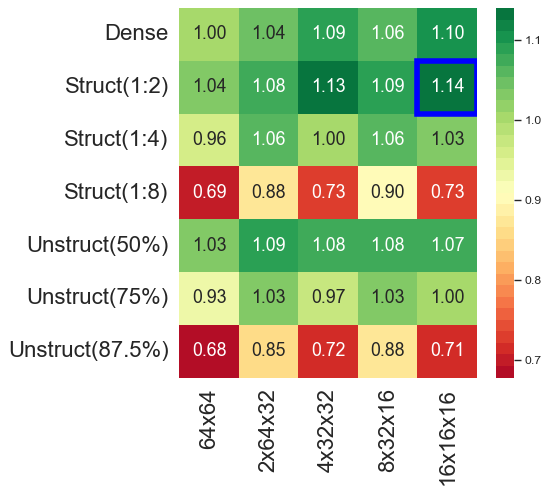

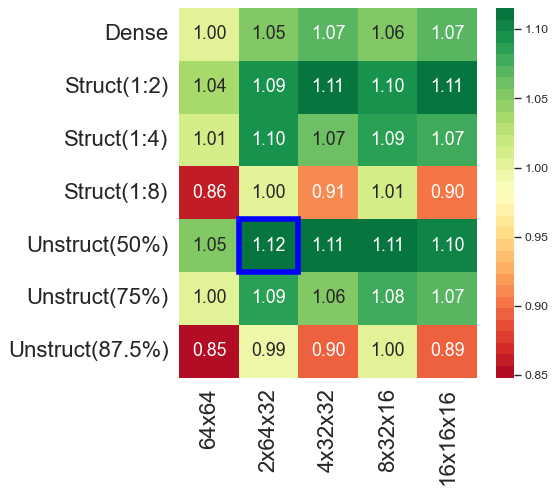

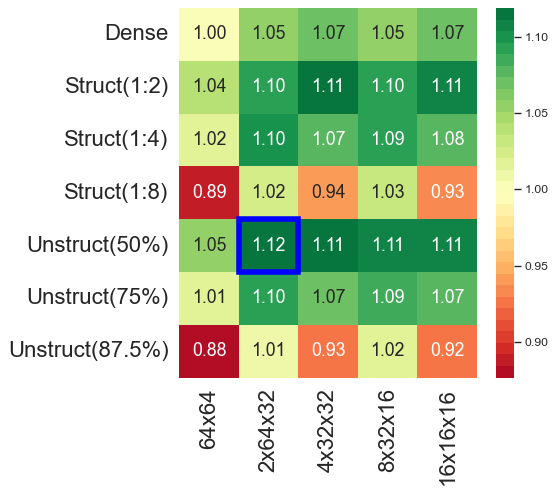

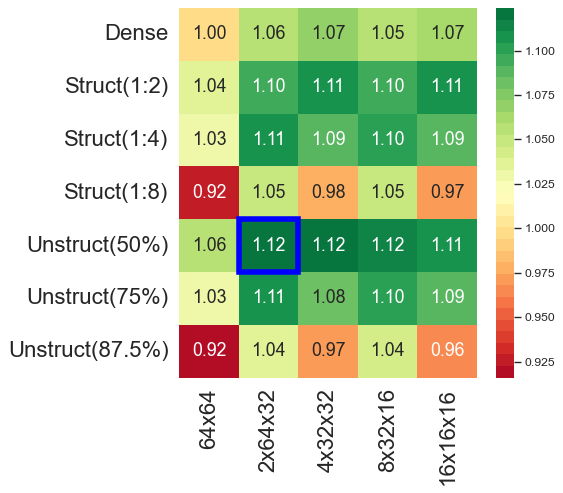

In [20]:
from matplotlib.patches import Rectangle

for energy_weight, data in zip([1,2,3,4],[data_edge_inference_1x_energy, data_edge_inference_2x_energy, data_edge_inference_3x_energy, data_edge_inference_4x_energy]):
  print(f"Plotting for data with {energy_weight}x energy weightage")
  df_edge_inference=pd.DataFrame(data)
  display(df_edge_inference)

  # from turtle import position

  fig = plt.figure(figsize=(6,6), dpi=80)

  x_axis_labels = []
  for shape in mxu_shapes:
    x_axis_labels += str(shape)
  y_axis_labels = ['Dense','Struct(1:2)','Struct(1:4)','Struct(1:8)','Unstruct(50%)','Unstruct(75%)','Unstruct(87.5%)']

  cmap = sns.mpl_palette("RdYlGn",32)
  ax = sns.heatmap(df_edge_inference, annot=True, fmt='0.2f', annot_kws={"fontsize":16},cmap=cmap,yticklabels=y_axis_labels , xticklabels=['64x64' , '2x64x32','4x32x32','8x32x16','16x16x16'])

  for label in ax.get_yticklabels():
    label.set_size(20) 

  for label in ax.get_xticklabels():
    label.set_size(20)  
  

  max_value = max(df_edge_inference.values.flatten())
  max_y, max_x = divmod(df_edge_inference.values.argmax(), df_edge_inference.shape[1])
  print(f' For {energy_weight}x energy weightage, max_value: {max_value}, at position:{mxu_shapes[max_x]},  {y_axis_labels[max_y]}')
  ax.add_patch(Rectangle((max_x, max_y), 1, 1, fill=False, edgecolor='blue', lw=5))
  plt.xticks(rotation=90) 


# plt.savefig('edge_inference.pdf', bbox_inches='tight', pad_inches=0)
# plt.show()

,0,1,2,3,4
0,1.00,1.04,1.09,1.06,1.10
1,1.04,1.08,1.13,1.09,1.14
2,0.96,1.06,1.00,1.06,1.03
3,0.69,0.88,0.73,0.90,0.73
4,1.03,1.09,1.08,1.08,1.07
5,0.93,1.03,0.97,1.03,1.00
6,0.68,0.85,0.72,0.88,0.71


1.1404483327015242


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0.5, 0, '64x64'),
  Text(1.5, 0, '2x64x32'),
  Text(2.5, 0, '4x32x32'),
  Text(3.5, 0, '8x32x16'),
  Text(4.5, 0, '16x16x16')])

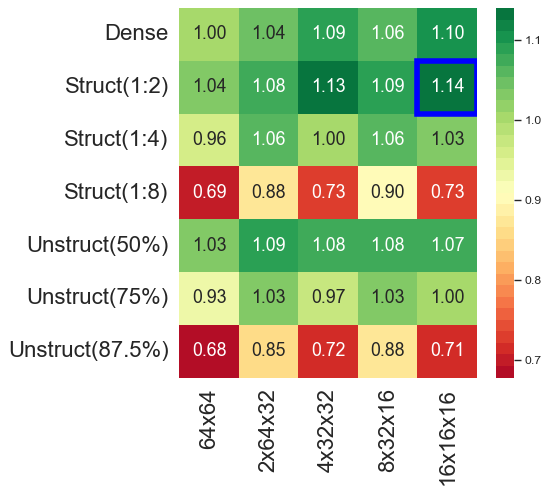

In [21]:
from matplotlib.patches import Rectangle

df_edge_inference=pd.DataFrame(data_edge_inference_1x_energy)
df_edge_inference_2x_energy = pd.DataFrame(data_edge_inference_2x_energy)
display(df_edge_inference)


# from turtle import position

fig = plt.figure(figsize=(6,6), dpi=80)

x_axis_labels = []
for shape in mxu_shapes:
   x_axis_labels += str(shape)
y_axis_labels = ['Dense','Struct(1:2)','Struct(1:4)','Struct(1:8)','Unstruct(50%)','Unstruct(75%)','Unstruct(87.5%)']

cmap = sns.mpl_palette("RdYlGn",32)
ax = sns.heatmap(df_edge_inference, annot=True, fmt='0.2f', annot_kws={"fontsize":16},cmap=cmap,yticklabels=y_axis_labels , xticklabels=['64x64' , '2x64x32','4x32x32','8x32x16','16x16x16'])

for label in ax.get_yticklabels():
  label.set_size(20) 

for label in ax.get_xticklabels():
  label.set_size(20)  
  

max_value = max(df_edge_inference.values.flatten())
print(max_value)
max_y, max_x = divmod(df_edge_inference.values.argmax(), df_edge_inference.shape[1])
ax.add_patch(Rectangle((max_x, max_y), 1, 1, fill=False, edgecolor='blue', lw=5))
plt.xticks(rotation=90) 

Training 1.766424993357689
Server Inf. 1.4264303559150027
Edge Inf. 1.1404483327015242
Edge Inf. (2x Energy) 1.1154162960815166


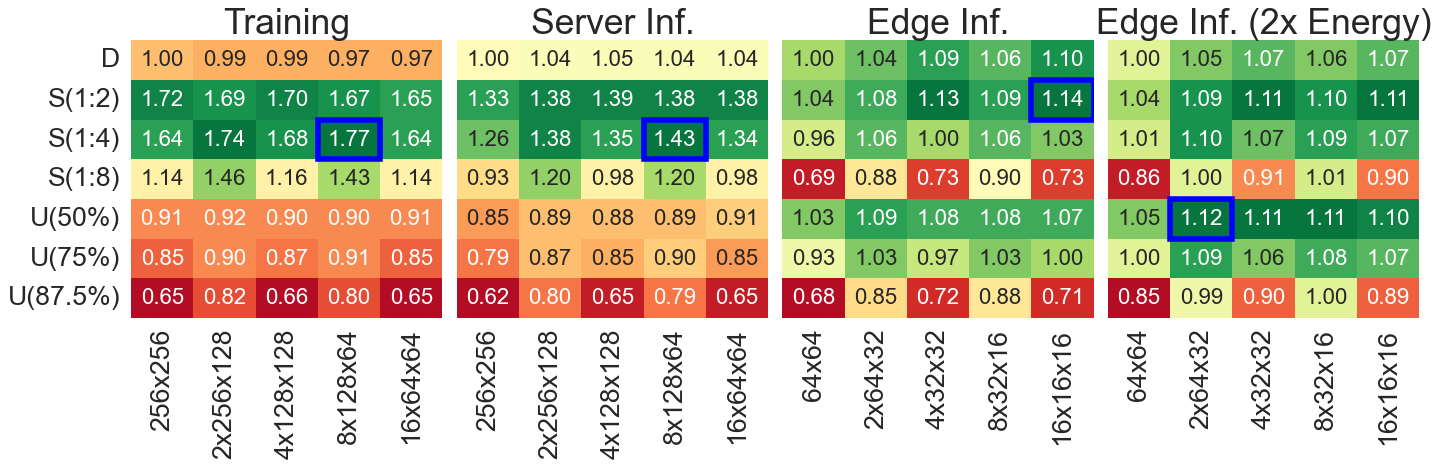

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# 1. SETUP DATA AND LABELS
# Assuming df_training, df_server_inference, df_edge_inference, df_edge_inference_2x_energy are defined
dataframes = [df_training, df_server_inference, df_edge_inference, df_edge_inference_2x_energy]

training_x_labels = ['256x256', '2x256x128', '4x128x128', '8x128x64', '16x64x64']
server_x_labels = ['256x256', '2x256x128', '4x128x128', '8x128x64', '16x64x64']
edge_x_labels = ['64x64', '2x64x32', '4x32x32', '8x32x16', '16x16x16']
edge_2x_energy_x_labels = ['64x64', '2x64x32', '4x32x32', '8x32x16', '16x16x16']    
x_axis_labels = [training_x_labels, server_x_labels, edge_x_labels, edge_2x_energy_x_labels]
y_axis_labels = ['D','S(1:2)','S(1:4)','S(1:8)','U(50%)','U(75%)','U(87.5%)']
titles = ['Training', 'Server Inf.', 'Edge Inf.', 'Edge Inf. (2x Energy)']

# 2. CALCULATE GLOBAL MIN/MAX FOR UNIFIED SCALE
# This ensures 0.5 is the same color in all three plots
v_min = min(df.values.min() for df in dataframes)
v_max = max(df.values.max() for df in dataframes)

fig, axes = plt.subplots(1, 4, figsize=(18, 6), dpi=80)
cmap = sns.mpl_palette("RdYlGn", 32)

for ax, df, title, x_labels in zip(axes, dataframes, titles, x_axis_labels):
    # 3. APPLY vmin AND vmax HERE
    sns.heatmap(df, annot=True, fmt='0.2f', annot_kws={"fontsize":20}, 
                cmap=cmap, cbar = False,
                # , vmin=v_min, vmax=v_max,
                yticklabels=y_axis_labels, xticklabels=x_labels, ax=ax)
    
    ax.set_title(title, fontsize=32)
    
    if title == 'Training':
        ax.tick_params(axis='y', labelsize=24, rotation=0)
    else:
        ax.tick_params(axis='y', labelleft=False)
        
    ax.tick_params(axis='x', labelsize=24, rotation=90)
    
    # Access the colorbar
    cbar = ax.collections[0].colorbar
    # cbar.ax.tick_params(labelsize=0)
    

    # Max value highlight logic
    max_value = max(df.values.flatten())
    print(title, max_value)
    max_y, max_x = divmod(df.values.argmax(), df.shape[1])
    ax.add_patch(Rectangle((max_x, max_y), 1, 1, fill=False, edgecolor='blue', lw=5))

plt.tight_layout()
plt.savefig('all_plots.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

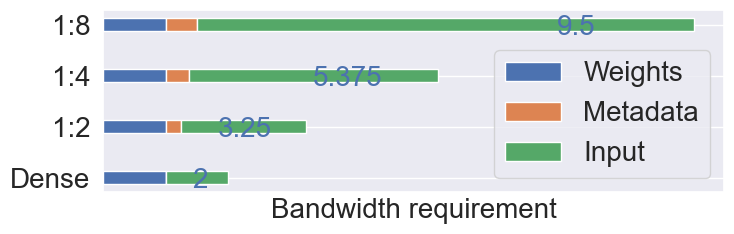

In [23]:
## Sparsity motivation for increased BW with sparsity
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [7.50, 2.5]
plt.rcParams["figure.autolayout"] = True
# Define the x-axis points
y_axis = ['Dense', '1:2', '1:4', '1:8']

# Define the values for each component
weights = [1, 1, 1, 1]
metadata = [0, 0.25, 0.375, 0.5]
input_ = [1, 2, 4, 8]

# Set the width of each bar
bar_height = 0.25

# Create the bar graph
fig, ax = plt.subplots()
ax.barh(y_axis, weights, height=bar_height, label='Weights')
ax.barh(y_axis, metadata, height=bar_height, left=weights, label='Metadata')
ax.barh(y_axis, input_, height=bar_height, left=np.add(weights, metadata), label='Input')

# plt.barh( weights, width=bar_width, label='Weights')
# plt.barh( metadata, width=bar_width, bottom=weights, label='Metadata')
# plt.barh( input_, width=bar_width, bottom=[i+j for i,j in zip(weights,metadata)], label='Input')

# Add labels and title to the graph
# ax.set_ylabel('Sparsity Supported in HW',fontsize=20)
ax.set_xlabel('Bandwidth requirement',fontsize=20)
# plt.title('Stacked Bar Graph with Components')
# ax.set_yticks(range(len(y_axis)),fontsize=20)
# ax.set_xticks(np.arange(0,10,2),fontsize=20)
ax.legend(fontsize = 20)
plt.yticks(fontsize=20)
plt.xticks([])

# Add total values at the top of each bar
for i, (w, m, inp) in enumerate(zip(weights, metadata, input_)):
    total = w + m + inp
    ax.text( total/1.2 , i -0.2 ,str(total), ha='right', fontsize=20, color='b')
# ax.swap_axes()
# Display the graph
plt.savefig('bw_requirement_scaling.pdf', bbox_inches='tight', pad_inches=0)
# plt.show()


In [24]:
## Figure 7, Area Breakdown for 16k PE with 128MB
### Area cost breakdown
unit = Unit()


single_sparsity_area = []
## Structured
for sparse_pe_support in [1,0.5,0.25,0.125]:       #,

    system = System(unit,frequency=1000 , flops=128 , offchip_mem_bw=1300 ,
                pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=32, mxu_shape = [2,2,128,128] )
    # print(system)
    area, BW = get_HW_cost(system,sparse_pe_support, print_distribution=True)
    single_sparsity_area.append(area)
    
## Unstructured
system = System(unit,frequency=1000 , flops=128 , offchip_mem_bw=900 ,
            pe_min_density_support=0.000001, model_on_chip_mem_implications=True, on_chip_mem_size=32, mxu_shape = [2,2,128,128],accelerator_type="unstructured" )
# print(system)
area, BW = get_HW_cost(system,sparse_pe_support, print_distribution=True)
single_sparsity_area.append(area)
# print(f"For i = {i}, area:{area}, BW = {BW}, and total Area:{area*(128/i)}")
# print("-----------------------------------------------------------")


For Num_Pes:16384, Num_cores:4
M ratio: 1  , num_inst: 268.435456 , num wrappers: 16 , num_inst per wrapper: 16
Rd_BW_required: 256 , memory_instance_BW: 16 , num mem insts: 268.435456 , Num wrappers: 16 , num_inst per wrapper: 16
12.032289850000002 7.031935205376 3.0450624000000004 6.0901272
 C:42.67 , M:24.94 , ICN:32.39
For Num_Pes:16384, Num_cores:4
M ratio: 1  , num_inst: 268.435456 , num wrappers: 16 , num_inst per wrapper: 16
Rd_BW_required: 256 , memory_instance_BW: 16 , num mem insts: 268.435456 , Num wrappers: 16 , num_inst per wrapper: 16
12.032289850000002 7.031935205376 3.0450624000000004 6.0901272
 C:42.67 , M:24.94 , ICN:32.39
For Num_Pes:16384, Num_cores:4
M ratio: 4  , num_inst: 268.435456 , num wrappers: 64 , num_inst per wrapper: 4
Rd_BW_required: 1024 , memory_instance_BW: 16 , num mem insts: 268.435456 , Num wrappers: 64 , num_inst per wrapper: 4
12.9242644 7.031935205376 3.04506624 51.7683876
 C:17.29 , M:9.40 , ICN:73.31
For Num_Pes:16384, Num_cores:4
M ratio: 8 

In [28]:
model_list =        ['Llama3_8B','Llama3_70B', 'Llama3_405B']
tensor_parallel_list = [1, 8, 16]
num_layers     =    [32,80, 126]
spff_density  =    [0.06125, 0.06125, 0.06125]
batch_size_list =     [8, 4, 4]
input_len_list   =    [ 8192 , 16384, 32*1024]

repetation_list = [a*b for a,b in zip(workload_ratio,num_layers)]

Max_Dim_list  = [16, 32, 64, 96,  128, 192, 256]

# 96, 112, 144, 160, 186, 204, 222, 240,
# mxu_shapes = [[1,1,Max_Dim,Max_Dim]]


unstruct_BW = 1
data_3D_plot = []

## Sparsity Sweep
for sparse_pe in [1,0.5,0.25,0.125,0.00001,0.00001,0.00001]:
# for sparse_pe in [0.00001]:
    if(sparse_pe == 0.00001):
        unstruct_BW *= 2
    row = []
    for Max_Dim in Max_Dim_list:
        if Max_Dim in [16, 32, 64, 128, 256]:
            mxu_shapes = [[1,1,Max_Dim,Max_Dim],[1,2,(Max_Dim//2),Max_Dim],[2,2,(Max_Dim//2),(Max_Dim//2)],[2,4,(Max_Dim//4),(Max_Dim//2)],[4,4,(Max_Dim//4),(Max_Dim//4)]]
        elif Max_Dim in [96, 192]:
            mxu_shapes = [[1,1,Max_Dim,Max_Dim],[1,2,(Max_Dim//2),Max_Dim],[2,2,(Max_Dim//2),(Max_Dim//2)],[2,3,(Max_Dim//3),(Max_Dim//2)],[3,3,(Max_Dim//3),(Max_Dim//3)]] 
        ## Shape sweep
        for shape in mxu_shapes:
            if shape[-1] <8 or shape[-2] < 8:
                continue
            # row.append(shape)
            for SRAM_size in [Max_Dim/32, Max_Dim/8, Max_Dim/4, Max_Dim/2, Max_Dim]:
                for off_chip_mem_bw in [100, 768, 1000, 4000, 8000, 16000]:
                    if(sparse_pe == 0.00001):
                        system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=off_chip_mem_bw ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=SRAM_size , mxu_shape=shape, accelerator_type="unstructured", compute_efficiency=(0.5 + 0.01*unstruct_BW))
                        system.set_pe_min_density_support(sparse_pe)
                    else:
                        system = System(unit,frequency=1000 , flops=Max_Dim/2 , offchip_mem_bw=off_chip_mem_bw ,pe_min_density_support=1, model_on_chip_mem_implications=True, on_chip_mem_size=SRAM_size , mxu_shape=shape, accelerator_type="structured")
                        system.set_pe_min_density_support(sparse_pe)
                    area, BW = get_HW_cost(system,sparse_pe_support=sparse_pe, print_distribution=False, unstructure_BW=unstruct_BW)

                    for model,repetation,sparsity,seq_len,batch_size, tp in zip(model_list,repetation_list,spff_density,input_len_list,batch_size_list, tensor_parallel_list):
                        ## Workload sweep
                        cycles = 0
                        energy = 0
                        # print(model,repetation,sparsity,seq_len,batch_size, tp)
                        generated_model = create_inference_moe_prefix_model(input_sequence_length=seq_len, output_gen_tokens = 0,
                            name=model,data_path=data_path, tensor_parallel=tp, method='sparse_FF',spff_density=sparsity)
                        model_df = get_model_df(generated_model, system, unit, batch_size, data_path, sparse=True, intermediate_on_chip=True )
                        # display_df(model_df)
                        df = get_summary_table(model_df,system,unit)
                        cycles = repetation * df.loc[0,'Cycles']/1000000
                        energy = repetation * df.loc[0,'Energy']
                        data_3D_plot.append([Max_Dim, shape, sparse_pe, SRAM_size, off_chip_mem_bw, model, cycles, energy, area])

                    # display_df(model_df)
                    print( f"For {shape} with {sparse_pe}sparsity Merit: {merit: 0.4f}, Cycles : {df.loc[0,'Cycles']/1000000 : 0.4f} , Energy:{df.loc[0,'Energy']: 0.4f} , area:{area: 0.4f}")
                # print(row)


For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 98025.2273 , area: 0.8178
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 98025.2273 , area: 0.8178
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 98025.2273 , area: 0.8178
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 98025.2273 , area: 0.8178
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 98025.2273 , area: 0.8178
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 98025.2273 , area: 0.8178
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 29185.3740 , area: 3.4686
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 29185.3740 , area: 3.4686
For [1, 1, 16, 16] with 1sparsity Merit:  2.9939, Cycles :  137438.9535 , Energy: 29185.3740 , area: 3.4686
For [1, 1, 16, 16] with 1spa

In [29]:
df_3D_plot = pd.DataFrame(data_3D_plot, columns=['Max_Dim', 'Shape', 'Sparse_PE', 'SRAM_size', 'Off Chip BW', 'Model', 'Cycles', 'Energy', 'Area'])
df_3D_plot['Cycles'] = df_3D_plot['Cycles'] * 1e-3
df_3D_plot['Energy'] = df_3D_plot['Energy'] * 1e-6

In [30]:
df_3D_plot

,Max_Dim,Shape,Sparse_PE,SRAM_size,Off Chip BW,Model,Cycles,Energy,Area
0,16,"[1, 1, 16, 16]",1.00,0.50,100,Llama3_8B,39719.86,93.50,0.82
1,16,"[1, 1, 16, 16]",1.00,0.50,100,Llama3_70B,43164.42,15.89,0.82
2,16,"[1, 1, 16, 16]",1.00,0.50,100,Llama3_405B,259759.62,185.27,0.82
3,16,"[1, 1, 16, 16]",1.00,0.50,768,Llama3_8B,39719.86,93.50,0.82
4,16,"[1, 1, 16, 16]",1.00,0.50,768,Llama3_70B,43164.42,15.89,0.82
...,...,...,...,...,...,...,...,...,...
20785,256,"[4, 4, 64, 64]",0.00,256.00,8000,Llama3_70B,119.64,1.32,1220.54
20786,256,"[4, 4, 64, 64]",0.00,256.00,8000,Llama3_405B,748.68,8.08,1220.54
20787,256,"[4, 4, 64, 64]",0.00,256.00,16000,Llama3_8B,112.40,0.99,1220.54
20788,256,"[4, 4, 64, 64]",0.00,256.00,16000,Llama3_70B,119.64,1.32,1220.54


In [31]:
df_3D_plot['Energy_optimized'] = df_3D_plot['Energy'] * df_3D_plot['Cycles']
df_3D_plot['Area_optimized'] =  df_3D_plot['Cycles'] * df_3D_plot['Area']
# Find rows with max Energy_optimized and min Area_optimized for each model
max_energy_rows = []
min_area_rows = []

for model in df_3D_plot['Model'].unique():
    model_data = df_3D_plot[df_3D_plot['Model'] == model]
    
    # Find row with maximum Energy_optimized
    max_energy_idx = model_data['Energy_optimized'].idxmin()
    max_energy_row = df_3D_plot.loc[max_energy_idx]
    max_energy_rows.append(max_energy_row)
    
    # Find row with minimum Area_optimized
    min_area_idx = model_data['Area_optimized'].idxmin()
    min_area_row = df_3D_plot.loc[min_area_idx]
    min_area_rows.append(min_area_row)

# Create DataFrames for the results
max_energy_df = pd.DataFrame(max_energy_rows)
min_area_df = pd.DataFrame(min_area_rows)

print("Rows with maximum Energy_optimized for each model:")
display(max_energy_df[['Model', 'Max_Dim', 'Shape', 'Sparse_PE', 'SRAM_size', 'Off Chip BW', 'Energy_optimized', 'Area']])

print("\nRows with minimum Area_optimized for each model:")
display(min_area_df[['Model', 'Max_Dim', 'Shape', 'Sparse_PE', 'SRAM_size', 'Off Chip BW', 'Area_optimized', 'Area']])


Rows with maximum Energy_optimized for each model:


,Model,Max_Dim,Shape,Sparse_PE,SRAM_size,Off Chip BW,Energy_optimized,Area
11487,Llama3_8B,256,"[1, 1, 256, 256]",0.12,128.00,768,69.34,1062.96
11452,Llama3_70B,256,"[1, 1, 256, 256]",0.12,32.00,768,98.22,942.03
11471,Llama3_405B,256,"[1, 1, 256, 256]",0.12,64.00,768,3749.19,982.34



Rows with minimum Area_optimized for each model:


,Model,Max_Dim,Shape,Sparse_PE,SRAM_size,Off Chip BW,Area_optimized,Area
5853,Llama3_8B,256,"[4, 4, 64, 64]",0.50,8.00,768,8527.89,79.52
5854,Llama3_70B,256,"[4, 4, 64, 64]",0.50,8.00,768,9205.64,79.52
5855,Llama3_405B,256,"[4, 4, 64, 64]",0.50,8.00,768,56104.40,79.52


0 Llama3_8B
1 Llama3_70B
2 Llama3_405B
3 Llama3_8B
4 Llama3_70B
5 Llama3_405B


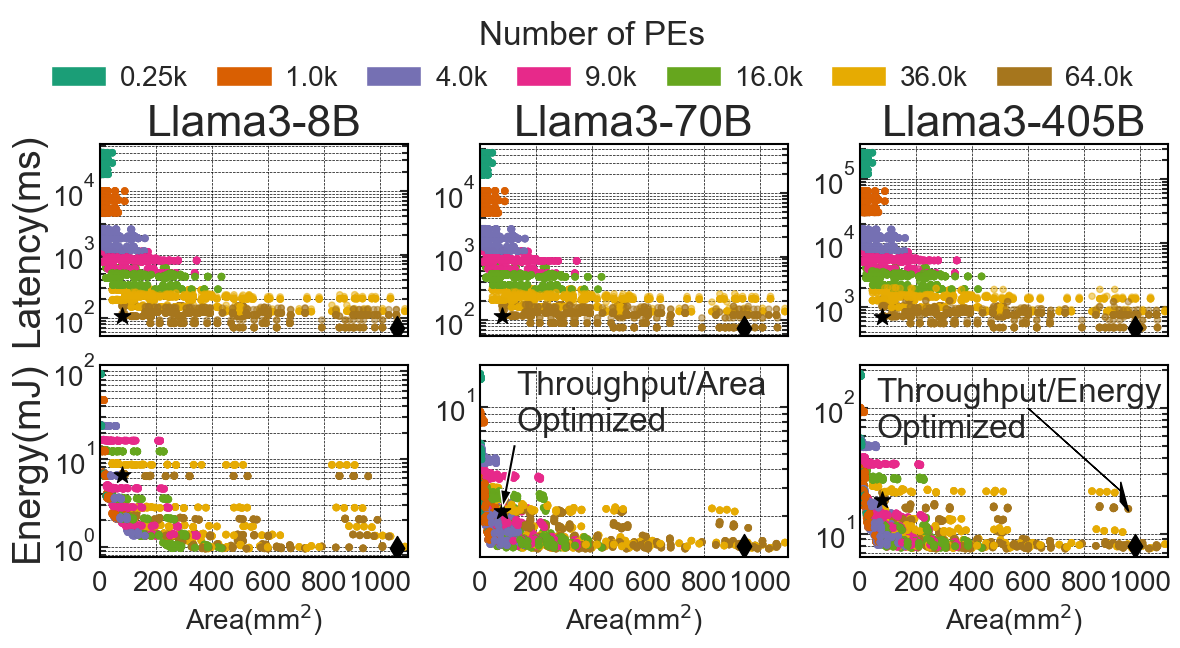

In [32]:
import matplotlib.pyplot as plt
df_3D_plot['Max_Dim'] = df_3D_plot['Max_Dim'].astype(str)

cmap = plt.cm.Dark2

colormap = {16:cmap(0), 32:cmap(1), 64:cmap(2), 96:cmap(3),  128:cmap(4), 192:cmap(5), 256:cmap(6)}
def create_colormap(x):
    return colormap[int(x)]
df_3D_plot['Color'] = df_3D_plot['Max_Dim'].map(create_colormap)


# Plotting area vs cycles
unique_models = df_3D_plot['Model'].nunique()

fig, axes = plt.subplots(nrows=2, ncols=unique_models, figsize=(12, 6), sharex=True, facecolor='white')
fig.patch.set_facecolor('white')  # Set figure background to white


for i, (ax, model) in enumerate(zip(axes.flatten(), model_list * 2)):
    model_data = df_3D_plot[df_3D_plot['Model'] == model]
    print(i, model)
    # First row: Area vs Cycles
    if i < unique_models:
        ax.set_facecolor('white')  # Set axis background to white
        scatter = ax.scatter(model_data['Area'], model_data['Cycles'], c=model_data['Color'], alpha=0.5, s=20)
        ax.set_title(f'{model.replace("_", "-")}', fontdict={'fontsize': 32})
        ax.set_xlim(0, 110)
        ax.set_yscale('log')
        if model == model_list[0]:
            ax.set_ylabel('Latency(ms)', fontdict={'fontsize': 28})
        # Add a box around the plot
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='black')
        ax.tick_params(axis='y', labelsize=20)
        # Add y tick marks
        # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0e}'))
        ax.yaxis.set_ticks_position('both')
        ax.yaxis.set_tick_params(which='both', direction='in', width=1.5)
        ax.scatter(min_area_df[min_area_df['Model'] == model]['Area'],
                    min_area_df[min_area_df['Model'] == model]['Cycles'],
                    color='black', s=150, marker='*')
        # display(min_area_df[min_area_df['Model'] == model])

        # display(max_energy_df[max_energy_df['Model'] == model])
        ax.scatter(max_energy_df[max_energy_df['Model'] == model]['Area'],
                    max_energy_df[max_energy_df['Model'] == model]['Cycles'],
                    color='black', s=150, marker='d')
        # print(max_energy_df[max_energy_df['Model'] == model]['Area'], max_energy_df[max_energy_df['Model'] == model]['Cycles'])            
    # Second row: Area vs Energy
    else:
        ax.set_facecolor('white')  # Set axis background to white
        scatter = ax.scatter(model_data['Area'], model_data['Energy'], c=model_data['Color'], alpha=0.5, s=20)
        # ax.set_title(f'{model}')
        ax.set_xlim(0, 1100)
        ax.set_xlabel('Area(mm$^2$)', fontsize=20)
        ax.set_yscale('log')
        if model == model_list[0]:
            ax.set_ylabel('Energy(mJ)', fontdict={'fontsize': 28})
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='black')
        ax.tick_params(axis='x', labelsize=20)
        ax.tick_params(axis='y', labelsize=20)
        ax.yaxis.set_ticks_position('both')
        ax.yaxis.set_tick_params(which='both', direction='in', width=1.5)
        ax.scatter(min_area_df[min_area_df['Model'] == model]['Area'],
                    min_area_df[min_area_df['Model'] == model]['Energy'],
                    color='black', s=150, marker='*')
        ax.scatter(max_energy_df[max_energy_df['Model'] == model]['Area'],
                    max_energy_df[max_energy_df['Model'] == model]['Energy'],
                    color='black', s=150, marker='d')

# Create a colorbar above the plots
# Create a legend for discrete colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Get unique Max_Dim values
unique_max_dims = [int(x) for x in Max_Dim_list]

# Create legend elements
legend_elements = []
for dim in unique_max_dims:
    legend_elements.append(Patch(facecolor=colormap[dim], label=str(dim*dim/1024)+'k'))

# Add a legend to the figure
fig.legend(handles=legend_elements,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.1),
            ncol=len(unique_max_dims),
            title='Number of PEs',
            fontsize=20,
            title_fontsize=24,
            columnspacing=1.0,
            handletextpad=0.5,
            frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the legend

# Add annotations for area optimal and energy optimal points
# Get the area optimal point
area_opt_point = min_area_df[min_area_df['Model'] == model_list[1]]
if not area_opt_point.empty:
    ax = axes[1,1]
    ax.annotate('Throughput/Area\nOptimized', 
                xy=(area_opt_point['Area'].values[0], area_opt_point['Energy'].values[0]),
                xytext=(area_opt_point['Area'].values[0] + 50, area_opt_point['Energy'].values[0] * 3.25),
                arrowprops=dict(facecolor='black', shrink=0.05, width=2.5, headwidth=8),
                fontsize=24)

energy_opt_point = max_energy_df[max_energy_df['Model'] == model_list[2]]
if not energy_opt_point.empty:
    ax = axes[1,2]
    ax.annotate('Throughput/Energy\nOptimized', 
                xy=(energy_opt_point['Area'].values[0], energy_opt_point['Energy'].values[0]),
                xytext=(energy_opt_point['Area'].values[0] - 925, energy_opt_point['Energy'].values[0] * 7.25),
                # arrowprops=dict(facecolor='black', shrink=0.05, width=2.5, headwidth=8),
                fontsize=24)
    ax.arrow(600, 100,
            360, -85,
    head_width=8,
    head_length=30,
    fc='black',
    ec='black',
    length_includes_head=True,
    head_starts_at_zero=False)
plt.savefig('sparse_acc_dse.pdf', bbox_inches='tight', pad_inches=0)


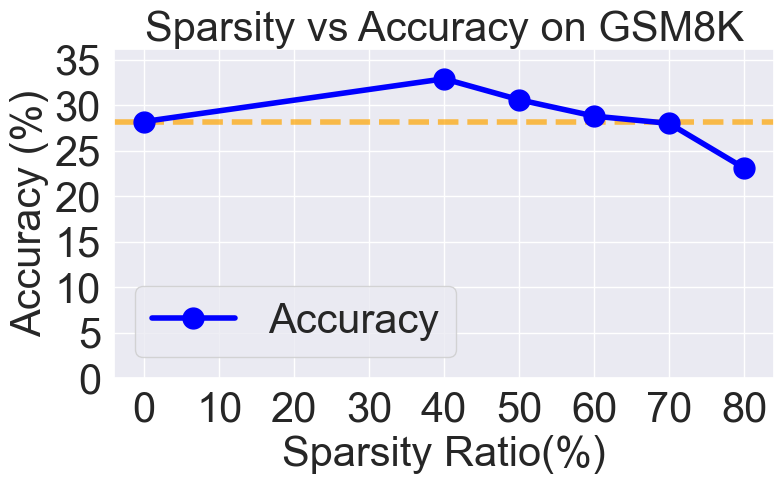

In [35]:
import matplotlib.pyplot as plt

# Data from table 3(https://arxiv.org/pdf/2310.06927)
sparsity = [0, 40, 50, 60, 70, 80]
accuracy = [28.2, 32.9, 30.6, 28.8, 28.0, 23.1]
# Plotting
plt.figure(figsize=(8, 5))
plt.axhline(y=accuracy[0], color='orange', linestyle='--', linewidth=4, alpha=0.7)  # Horizontal line at sparsity=0 accuracy

plt.plot(sparsity, accuracy, marker='o', markersize=15, linestyle='-', linewidth=4, color='blue', label='Accuracy')
plt.title("Sparsity vs Accuracy on GSM8K", fontsize=30)
plt.xlabel("Sparsity Ratio(%)", fontsize=30)

plt.ylabel("Accuracy (%)", fontsize=30)
plt.ylim(0, max(accuracy) * 1.1)  # Start y-axis from 0
plt.grid(True)
plt.legend(fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.savefig("Sparsity_vs_Accuracy.pdf", format='pdf', bbox_inches='tight', dpi=100)
plt.show()

